In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
dev_sample = pd.read_csv("../data/samples/criteo_sample.csv")

dev_sample.shape

(139796, 16)

In [3]:
# Preview the treatment and outcome variables
dev_sample[["treatment", "conversion", "visit"]].head()

,treatment,conversion,visit
0,0,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [4]:
# Check treatment group distribution
dev_sample["treatment"].value_counts()

treatment
1    118748
0     21048
Name: count, dtype: int64

In [5]:
# Check outcome combinations
dev_sample[["conversion", "visit"]].value_counts()

conversion  visit
0           0        133188
            1          6171
1           1           437
Name: count, dtype: int64

In [6]:
# Check for missing values
dev_sample[["treatment", "conversion", "visit"]].isna().sum()

treatment     0
conversion    0
visit         0
dtype: int64

In [7]:
# Generalized validation summary
validation_summary = {
    "Rows checked": len(dev_sample),
    "Treatment groups": sorted(dev_sample["treatment"].dropna().unique().tolist()),
    "Treatment group count": dev_sample["treatment"].nunique(),
    "Conversion values": sorted(dev_sample["conversion"].dropna().unique().tolist()),
    "Visit values": sorted(dev_sample["visit"].dropna().unique().tolist()),
    "Missing treatment values": dev_sample["treatment"].isna().sum(),
    "Missing conversion values": dev_sample["conversion"].isna().sum(),
    "Missing visit values": dev_sample["visit"].isna().sum(),
}

for key, value in validation_summary.items():
    print(f"{key}: {value}")

Rows checked: 139796
Treatment groups: [0, 1]
Treatment group count: 2
Conversion values: [0, 1]
Visit values: [0, 1]
Missing treatment values: 0
Missing conversion values: 0
Missing visit values: 0


**Conclusion:** The treatment and outcome variables contain the expected binary values with no missing observations. The development sample therefore passes the basic data validation and is suitable for proceeding with the incrementality analysis.

In [8]:
#treatment vs control conversion rates
conversion_rates = (
    dev_sample
    .groupby("treatment")["conversion"]
    .mean()
)

conversion_rates

treatment
0    0.001615
1    0.003394
Name: conversion, dtype: float64

In [9]:
#create variables for control and treatment conversion rates
control_conv_rate = conversion_rates.loc[0]
treatment_conv_rate = conversion_rates.loc[1]

control_conv_rate, treatment_conv_rate

(np.float64(0.0016153553781832002), np.float64(0.003393741368275676))

In [10]:
#treatement vs control visit rates
visit_rates = (
    dev_sample
    .groupby("treatment")["visit"]
    .mean()
)

visit_rates

treatment
0    0.039671
1    0.048616
Name: visit, dtype: float64

In [11]:
#create variables for control and treatement visit rates
control_visit_rate = visit_rates.loc[0]
treatment_visit_rate = visit_rates.loc[1]

control_visit_rate, treatment_visit_rate

(np.float64(0.03967122767008742), np.float64(0.04861555563041062))

In [12]:
#This is the percentage-point difference between treatment and control:
absolute_conversion_lift = (
    treatment_conv_rate - control_conv_rate
)

absolute_conversion_lift

np.float64(0.0017783859900924758)

In [13]:
#This measures the treatment improvement relative to the control baseline.
relative_conversion_lift = (
    (treatment_conv_rate - control_conv_rate)
    / control_conv_rate
)

relative_conversion_lift

np.float64(1.1009255388078363)

In [14]:
#This tells you the percentage-point change in visit rate caused by treatment.
absolute_visit_lift = (
    treatment_visit_rate - control_visit_rate
)

absolute_visit_lift

np.float64(0.008944327960323198)

In [15]:
#This tells you the relative increase/decrease in visits compared with control.
relative_visit_lift = (
    (treatment_visit_rate - control_visit_rate)
    / control_visit_rate
)

relative_visit_lift

np.float64(0.22546133522021877)

In [16]:
#create a summary table
incrementality_summary = pd.DataFrame({
    "Metric": [
        "Conversion Rate",
        "Visit Rate"
    ],
    "Control": [
        control_conv_rate,
        control_visit_rate
    ],
    "Treatment": [
        treatment_conv_rate,
        treatment_visit_rate
    ],
    "Absolute Lift": [
        absolute_conversion_lift,
        absolute_visit_lift
    ],
    "Relative Lift": [
        relative_conversion_lift,
        relative_visit_lift
    ]
})

incrementality_summary

incrementality_summary.style.format({
    "Control": "{:.2%}",
    "Treatment": "{:.2%}",
    "Absolute Lift": "{:.2%}",
    "Relative Lift": "{:.2%}"
})

,Metric,Control,Treatment,Absolute Lift,Relative Lift
0,Conversion Rate,0.16%,0.34%,0.18%,110.09%
1,Visit Rate,3.97%,4.86%,0.89%,22.55%


In [17]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

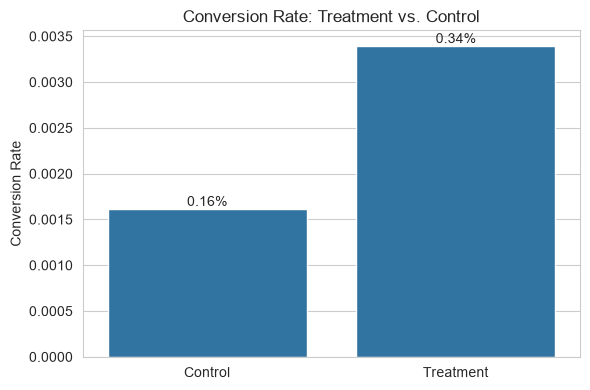

In [18]:
#Visualization: Treatment vs. Control Conversion Rate
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=["Control", "Treatment"],
    y=[control_conv_rate, treatment_conv_rate],
    ax=ax
)

ax.set_ylabel("Conversion Rate")
ax.set_xlabel("")
ax.set_title("Conversion Rate: Treatment vs. Control")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        labels=[
            f"{control_conv_rate:.2%}",
            f"{treatment_conv_rate:.2%}"
        ]
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/conversion_rate_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

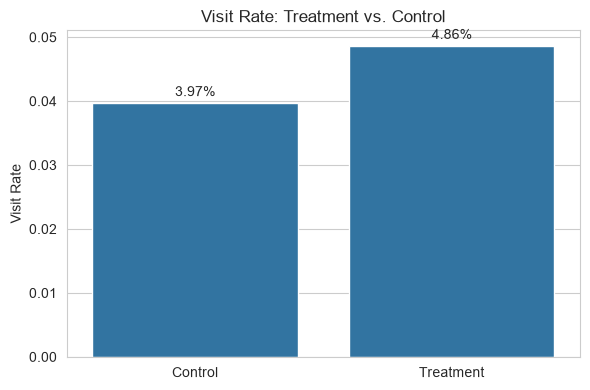

In [19]:
# Visualization: Treatment vs. Control Visit Rate
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=["Control", "Treatment"],
    y=[control_visit_rate, treatment_visit_rate],
    ax=ax
)

ax.set_ylabel("Visit Rate")
ax.set_xlabel("")
ax.set_title("Visit Rate: Treatment vs. Control")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{control_visit_rate:.2%}",
            f"{treatment_visit_rate:.2%}"
        ],
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/visit_rate_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

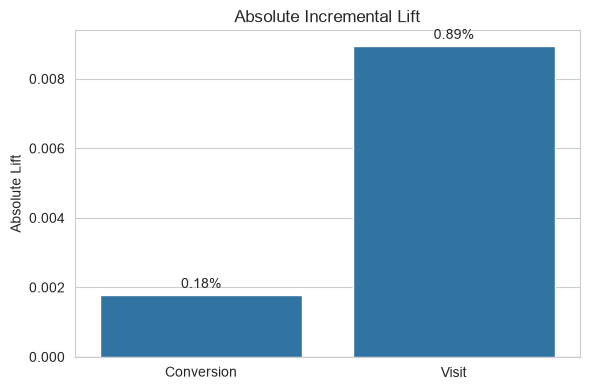

In [20]:
# Visualization: Absolute Lift
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=["Conversion", "Visit"],
    y=[absolute_conversion_lift, absolute_visit_lift],
    ax=ax
)

ax.set_ylabel("Absolute Lift")
ax.set_xlabel("")
ax.set_title("Absolute Incremental Lift")

ax.axhline(
    0,
    linewidth=0.8
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{absolute_conversion_lift:.2%}",
            f"{absolute_visit_lift:.2%}"
        ],
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/absolute_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

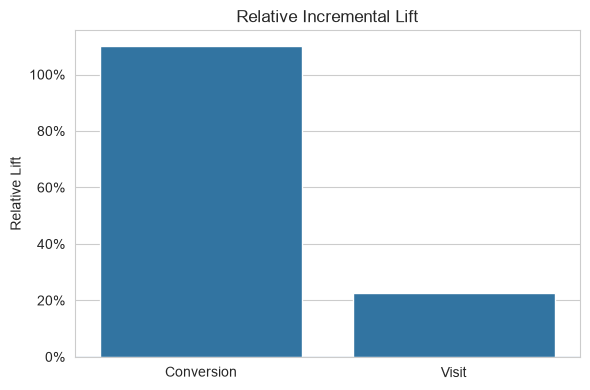

In [21]:
#Visualization: Relative Lift
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=["Conversion", "Visit"],
    y=[relative_conversion_lift, relative_visit_lift],
    ax=ax
)

ax.set_ylabel("Relative Lift")
ax.set_xlabel("")
ax.set_title("Relative Incremental Lift")

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.axhline(
    0,
    linewidth=0.8
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/relative_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [22]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

In [23]:
incrementality_summary.to_csv(
    "../outputs/tables/incrementality_summary.csv",
    index=False
)

In [24]:
os.path.exists("../outputs/tables/incrementality_summary.csv")

True

## Statistical Validation Note

The incrementality analysis in this notebook uses the **1% development sample (139,796 rows)** for fast development and validation.

The sample contains approximately **437 conversion events**, providing sufficient observations for an initial two-proportion z-test during development. The preliminary test produced a **z-statistic of approximately 4.3**, indicating a statistically significant difference between treatment and control conversion rates at this development stage.

However, this result is not used as the project's final statistical claim.

In **Step 3**, the conversion-rate difference will be re-evaluated using the **full 13.98M-row Criteo dataset**. The full dataset will be used to calculate the authoritative:

- Two-proportion z-statistic
- p-value
- 95% confidence interval
- Statistical significance conclusion

This ensures that the project's final statistical claim is based on the complete dataset rather than the development sample.

# Step 3 — Statistically Validate Incrementality

The previous step established the observed difference in conversion rates between the treatment and control groups using the 1% development sample.

This step statistically evaluates whether the observed treatment-control difference is unlikely to be due to random variation.

The analysis uses the **full Criteo dataset** to produce the final statistical results. A **two-proportion z-test** is used to test the difference in conversion rates, followed by a **95% confidence interval** for the conversion-rate difference.

The statistical analysis is performed manually using `numpy` and `scipy.stats.norm`, without a modeling library.

## 3.1 — Define the Hypotheses

### Null Hypothesis (H₀)

There is **no difference in conversion rates** between the treatment and control groups.

\[
H_0: p_{treatment} = p_{control}
\]

### Alternative Hypothesis (H₁)

There is a **difference in conversion rates** between the treatment and control groups.

\[
H_1: p_{treatment} \neq p_{control}
\]

This is a **two-sided test** because the analysis tests for any difference between treatment and control, rather than assuming in advance that treatment must increase conversion.

The statistical significance level is:

\[
\alpha = 0.05
\]

In [25]:
# Import statistical libraries

import numpy as np
from scipy.stats import norm

In [26]:
# Load only the columns required for statistical validation
full_counts = pd.read_csv(
    "../data/raw/criteo/criteo-research-uplift-v2.1.csv.gz",
    compression="gzip",
    usecols=["treatment", "conversion"],
    dtype={
        "treatment": "int8",
        "conversion": "int8"
    }
)
full_counts.shape

(13979592, 2)

In [27]:
#aggregate conversion counts by treatment group
full_grouped = (
    full_counts
    .groupby("treatment")["conversion"]
    .agg(["sum", "count"])
)

full_grouped

,sum,count
treatment,,
0,4063,2096937
1,36711,11882655


In [28]:
#extract control and treatment conversion counts and totals
control_conversions = int(full_grouped.loc[0, "sum"])
control_total = int(full_grouped.loc[0, "count"])

treatment_conversions = int(full_grouped.loc[1, "sum"])
treatment_total = int(full_grouped.loc[1, "count"])

print("Control conversions:", control_conversions)
print("Control total:", control_total)
print("Treatment conversions:", treatment_conversions)
print("Treatment total:", treatment_total)

Control conversions: 4063
Control total: 2096937
Treatment conversions: 36711
Treatment total: 11882655


In [29]:
#calculate full dataset conversion rates
control_conv_rate_full = (
    control_conversions / control_total
)

treatment_conv_rate_full = (
    treatment_conversions / treatment_total
)

print(f"Control conversion rate: {control_conv_rate_full:.4%}")
print(f"Treatment conversion rate: {treatment_conv_rate_full:.4%}")

Control conversion rate: 0.1938%
Treatment conversion rate: 0.3089%


In [30]:
#run the two proportion z-test to determine if the difference in conversion rates is statistically significant
#calculate the pooled conversion proportion
pooled_conversion_rate = (
    (treatment_conversions + control_conversions)
    / (treatment_total + control_total)
)

print(f"Pooled conversion rate: {pooled_conversion_rate:.4%}")

#calculate the pooled standard error
pooled_se = np.sqrt(
    pooled_conversion_rate
    * (1 - pooled_conversion_rate)
    * (
        (1 / treatment_total)
        + (1 / control_total)
    )
)

print(f"Pooled standard error: {pooled_se:.8f}")

#difference in conversion rates
conversion_rate_difference = (
    treatment_conv_rate_full
    - control_conv_rate_full
)

print(
    f"Absolute conversion lift: "
    f"{conversion_rate_difference:.4%}"
)

#calculate the z-statistics
z_statistic = (
    conversion_rate_difference
    / pooled_se
)

print(f"Z-statistic: {z_statistic:.4f}")

#calculate the two sided p-value
p_value = 2 * norm.sf(abs(z_statistic))

print(f"P-value: {p_value:.6g}")

Pooled conversion rate: 0.2917%
Pooled standard error: 0.00004039
Absolute conversion lift: 0.1152%
Z-statistic: 28.5165
P-value: 7.30826e-179


In [31]:
#Compute the 95% Confidence Interval
#unpooled standard error
unpooled_se = np.sqrt(
    (
        treatment_conv_rate_full
        * (1 - treatment_conv_rate_full)
        / treatment_total
    )
    +
    (
        control_conv_rate_full
        * (1 - control_conv_rate_full)
        / control_total
    )
)

print(f"Unpooled standard error: {unpooled_se:.8f}")

#margin of error
margin_of_error = 1.96 * unpooled_se

print(f"Margin of error: {margin_of_error:.4%}")

#confidence interval
ci_lower = (
    conversion_rate_difference
    - margin_of_error
)

ci_upper = (
    conversion_rate_difference
    + margin_of_error
)

print(f"95% CI lower bound: {ci_lower:.4%}")
print(f"95% CI upper bound: {ci_upper:.4%}")

Unpooled standard error: 0.00003437
Margin of error: 0.0067%
95% CI lower bound: 0.1085%
95% CI upper bound: 0.1219%


In [32]:
#Assemble the Full Reported Result
relative_conversion_lift_full = (
    conversion_rate_difference
    / control_conv_rate_full
)

print(
    f"Relative conversion lift: "
    f"{relative_conversion_lift_full:.2%}"
)

Relative conversion lift: 59.45%


In [33]:
#create final results table
statistical_result = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Absolute Conversion Lift",
        "Relative Conversion Lift",
        "Z-Statistic",
        "P-Value",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        control_conv_rate_full,
        treatment_conv_rate_full,
        conversion_rate_difference,
        relative_conversion_lift_full,
        z_statistic,
        p_value,
        ci_lower,
        ci_upper
    ]
})

statistical_result

,Metric,Value
0,Control Conversion Rate,1.937588e-03
1,Treatment Conversion Rate,3.089461e-03
2,Absolute Conversion Lift,1.151873e-03
3,Relative Conversion Lift,5.944881e-01
4,Z-Statistic,2.851653e+01
5,P-Value,7.308263e-179
6,95% CI Lower,1.084505e-03
7,95% CI Upper,1.219242e-03


In [34]:
#create a readable display table 
statistical_result_display = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Absolute Conversion Lift",
        "Relative Conversion Lift",
        "Z-Statistic",
        "P-Value",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        f"{control_conv_rate_full:.4%}",
        f"{treatment_conv_rate_full:.4%}",
        f"{conversion_rate_difference:.4%}",
        f"{relative_conversion_lift_full:.2%}",
        f"{z_statistic:.4f}",
        f"{p_value:.6g}",
        f"{ci_lower:.4%}",
        f"{ci_upper:.4%}"
    ]
})

statistical_result_display

,Metric,Value
0,Control Conversion Rate,0.1938%
1,Treatment Conversion Rate,0.3089%
2,Absolute Conversion Lift,0.1152%
3,Relative Conversion Lift,59.45%
4,Z-Statistic,28.5165
5,P-Value,7.30826e-179
6,95% CI Lower,0.1085%
7,95% CI Upper,0.1219%


In [35]:
#save the statistical results to a CSV file
import os

os.makedirs("../outputs/tables", exist_ok=True)

statistical_result.to_csv(
    "../outputs/tables/incrementality_statistical_test.csv",
    index=False
)

os.path.exists(
    "../outputs/tables/incrementality_statistical_test.csv"
)

True

## 3.6 — Business Interpretation

The full 13.98M-row Criteo dataset shows a clear difference in conversion rates between the treatment and control groups.

The control group has a conversion rate of **0.1938%**, compared with **0.3089%** for the treatment group. This represents an **absolute conversion lift of 0.1152 percentage points** and a **relative conversion lift of 59.45%**.

The two-proportion z-test produces a **z-statistic of 28.5165** and a **two-sided p-value of 7.31 × 10⁻¹⁷⁹**, which is far below the 0.05 significance threshold. Therefore, the null hypothesis of equal conversion rates is rejected.

The 95% confidence interval for the treatment-control conversion-rate difference is **[0.1085%, 0.1219%]**. Because the entire interval is above zero, the data are consistent with a positive treatment effect rather than no difference.

### Business Interpretation

The results provide strong statistical evidence of a positive incremental response among customers exposed to the treatment. The treatment group converted at approximately **59.45% higher relative conversion rate** than the control group, with the estimated absolute improvement being **0.1152 percentage points**.

However, statistical significance alone does not establish causality. The causal interpretation comes from the **randomized treatment/control experimental design**; the statistical test establishes that the observed difference is unlikely to be explained by random variation alone.

It is also important to distinguish **statistical significance from practical significance**. With approximately 13.98M observations, even relatively small differences can produce extremely small p-values. Therefore, the **0.1152 percentage-point absolute lift** should be considered alongside business factors such as incremental conversions, campaign cost, and return on promotional spend when evaluating whether the treatment is commercially worthwhile.

# Step 4 — Identify High-Response Customer Segments

The overall treatment effect established in Step 3 does not imply that all customers respond equally to the offer.

This step investigates whether incremental conversion varies across customer and campaign-related feature values (`f0`–`f11`). The objective is to identify segments where treatment produces comparatively stronger incremental response.

The analysis will:

1. Explore the distributions of `f0`–`f11` and their relationship with conversion and treatment.
2. Select a small number of candidate features showing meaningful variation or an observable relationship with response.
3. Convert selected continuous features into discrete segments using appropriate bins.
4. Calculate treatment/control conversion rates and incremental lift for each segment.
5. Evaluate segments using lift, sample size, and statistical reliability.
6. Visualize the strongest segment-level differences.


In [36]:
#Explore `f0`–`f11` using distributions, missingness, uniqueness, and descriptive statistics.
#Compare conversion rates and treatment/control composition across feature values or ranges.
#Identify features with meaningful variation and observable relationships with response for segmentation.

In [37]:
#identify the feature columns
feature_cols = [f"f{i}" for i in range(12)]

feature_cols

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

In [38]:
#inspect feature structure
full_counts.columns

Index(['treatment', 'conversion'], dtype='str')

In [39]:
#load the features needed for exploration
segment_data = pd.read_csv(
    "../data/raw/criteo/criteo-research-uplift-v2.1.csv.gz",
    compression="gzip",
    usecols=[
        "treatment",
        "conversion",
        *feature_cols
    ]
)
segment_data.shape

(13979592, 14)

In [40]:
#descriptive statistics for the features
segment_data[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
f0,13979592.0,19.620297,5.377464,12.616365,12.616365,21.923413,24.436459,26.745255
f1,13979592.0,10.069977,0.104756,10.059654,10.059654,10.059654,10.059654,16.344187
f2,13979592.0,8.446582,0.299316,8.214383,8.214383,8.214383,8.723335,9.051962
f3,13979592.0,4.178923,1.336645,-8.398387,4.679882,4.679882,4.679882,4.679882
f4,13979592.0,10.338837,0.343308,10.280525,10.280525,10.280525,10.280525,21.123508
f5,13979592.0,4.028513,0.431097,-9.011892,4.115453,4.115453,4.115453,4.115453
f6,13979592.0,-4.155356,4.577914,-31.429784,-6.699321,-2.411115,0.294443,0.294443
f7,13979592.0,5.101765,1.205248,4.833815,4.833815,4.833815,4.833815,11.998401
f8,13979592.0,3.933581,0.056660,3.635107,3.910792,3.971858,3.971858,3.971858
f9,13979592.0,16.027638,7.018975,13.190056,13.190056,13.190056,13.190056,75.295017


In [41]:
#check for unique and missing values
feature_summary = pd.DataFrame({
    "feature": feature_cols,
    "unique_values": [
        segment_data[f].nunique()
        for f in feature_cols
    ],
    "missing_values": [
        segment_data[f].isna().sum()
        for f in feature_cols
    ]
})

feature_summary

,feature,unique_values,missing_values
0,f0,2181959,0
1,f1,60,0
2,f2,2051900,0
3,f3,552,0
4,f4,260,0
5,f5,132,0
6,f6,1645,0
7,f7,622143,0
8,f8,3743,0
9,f9,1594,0


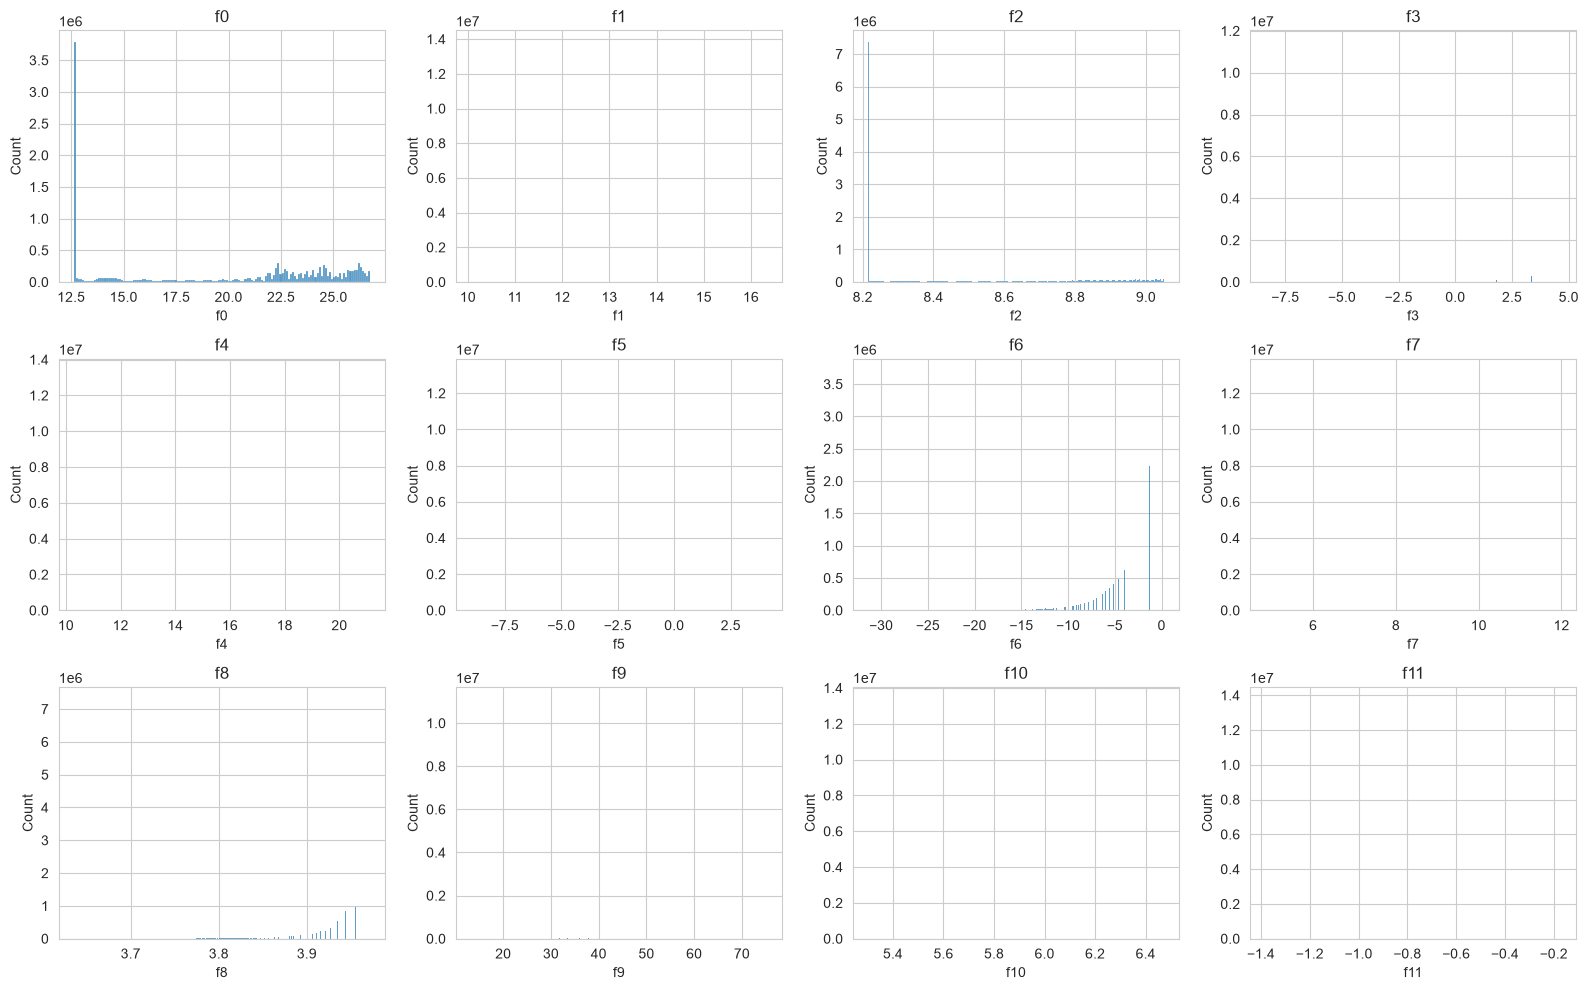

In [42]:
#explore feature distributions using histograms
fig, axes = plt.subplots(
    3, 4,
    figsize=(16, 10)
)

for feature, ax in zip(feature_cols, axes.flat):
    sns.histplot(
        data=segment_data,
        x=feature,
        ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/feature_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [43]:
#explore feature relationships with conversion rates 
feature_summary.sort_values(
    "unique_values",
    ascending=True
)

,feature,unique_values,missing_values
1,f1,60,0
5,f5,132,0
11,f11,136,0
4,f4,260,0
3,f3,552,0
9,f9,1594,0
6,f6,1645,0
8,f8,3743,0
10,f10,517372,0
7,f7,622143,0


In [44]:
#create temporary quartile bins for exploration
exploration_data = segment_data.copy()

for feature in feature_cols:
    exploration_data[f"{feature}_bin"] = pd.qcut(
        exploration_data[feature],
        q=4,
        duplicates="drop"
    )

#calculate conversion rates
feature_conversion_rates = {}

for feature in feature_cols:
    feature_conversion_rates[feature] = (
        exploration_data
        .groupby(f"{feature}_bin", observed=True)["conversion"]
        .mean()
    )

feature_conversion_rates

{'f0': f0_bin
 (12.615, 21.923]    0.005230
 (21.923, 24.436]    0.000774
 (24.436, 26.745]    0.000433
 Name: conversion, dtype: float64,
 'f1': f1_bin
 (10.059000000000001, 16.344]    0.002917
 Name: conversion, dtype: float64,
 'f2': f2_bin
 (8.213000000000001, 8.723]    0.003643
 (8.723, 9.052]                0.000738
 Name: conversion, dtype: float64,
 'f3': f3_bin
 (-8.399, 4.68]    0.002917
 Name: conversion, dtype: float64,
 'f4': f4_bin
 (10.280000000000001, 21.124]    0.002917
 Name: conversion, dtype: float64,
 'f5': f5_bin
 (-9.013, 4.115]    0.002917
 Name: conversion, dtype: float64,
 'f6': f6_bin
 (-31.431, -6.699]    0.007542
 (-6.699, -2.411]     0.001220
 (-2.411, 0.294]      0.001357
 Name: conversion, dtype: float64,
 'f7': f7_bin
 (4.832999999999999, 11.998]    0.002917
 Name: conversion, dtype: float64,
 'f8': f8_bin
 (3.634, 3.911]    0.010908
 (3.911, 3.972]    0.000207
 Name: conversion, dtype: float64,
 'f9': f9_bin
 (13.189, 75.295]    0.002917
 Name: convers

In [45]:
#calculate conversion rate range
feature_response_summary = []

for feature in feature_cols:
    rates = feature_conversion_rates[feature]

    feature_response_summary.append({
        "feature": feature,
        "min_conversion_rate": rates.min(),
        "max_conversion_rate": rates.max(),
        "conversion_rate_range": rates.max() - rates.min()
    })

feature_response_summary = pd.DataFrame(
    feature_response_summary
).sort_values(
    "conversion_rate_range",
    ascending=False
)

feature_response_summary

,feature,min_conversion_rate,max_conversion_rate,conversion_rate_range
8,f8,0.000207,0.010908,0.010701
6,f6,0.001220,0.007542,0.006322
0,f0,0.000433,0.005230,0.004797
2,f2,0.000738,0.003643,0.002905
3,f3,0.002917,0.002917,0.000000
1,f1,0.002917,0.002917,0.000000
5,f5,0.002917,0.002917,0.000000
4,f4,0.002917,0.002917,0.000000
7,f7,0.002917,0.002917,0.000000
9,f9,0.002917,0.002917,0.000000


## 4.2 — Validate Feature Screening

The initial screening identifies `f8`, `f6`, `f0`, and `f2` as the strongest candidates based on variation in conversion rate across quartile ranges.

Before selecting the final segmentation features, the remaining features are checked to determine whether their zero conversion-rate range reflects genuinely limited response variation or a limitation caused by their value distributions and quartile binning.

The candidate features will then be evaluated based on both response variation and their potential to distinguish treatment effectiveness across customer segments.

In [46]:
#inspect quartile bins
for feature in feature_cols:
    print(f"\n{feature}")
    print(
        exploration_data[f"{feature}_bin"]
        .value_counts(dropna=False)
        .sort_index()
    )


f0
f0_bin
(12.615, 21.923]    6989796
(21.923, 24.436]    3494900
(24.436, 26.745]    3494896
Name: count, dtype: int64

f1
f1_bin
(10.059000000000001, 16.344]    13979592
Name: count, dtype: int64

f2
f2_bin
(8.213000000000001, 8.723]    10484694
(8.723, 9.052]                 3494898
Name: count, dtype: int64

f3
f3_bin
(-8.399, 4.68]    13979592
Name: count, dtype: int64

f4
f4_bin
(10.280000000000001, 21.124]    13979592
Name: count, dtype: int64

f5
f5_bin
(-9.013, 4.115]    13979592
Name: count, dtype: int64

f6
f6_bin
(-31.431, -6.699]    3622644
(-6.699, -2.411]     4418921
(-2.411, 0.294]      5938027
Name: count, dtype: int64

f7
f7_bin
(4.832999999999999, 11.998]    13979592
Name: count, dtype: int64

f8
f8_bin
(3.634, 3.911]     3539789
(3.911, 3.972]    10439803
Name: count, dtype: int64

f9
f9_bin
(13.189, 75.295]    13979592
Name: count, dtype: int64

f10
f10_bin
(5.2989999999999995, 6.474]    13979592
Name: count, dtype: int64

f11
f11_bin
(-1.3849999999999998, -0.169]

In [47]:
#number of effective bins for each feature
bin_summary = []

for feature in feature_cols:
    bin_summary.append({
        "feature": feature,
        "unique_values": segment_data[feature].nunique(),
        "effective_bins": exploration_data[f"{feature}_bin"].nunique(
            dropna=True
        )
    })

bin_summary = pd.DataFrame(bin_summary)

bin_summary.sort_values(
    "effective_bins",
    ascending=True
)

,feature,unique_values,effective_bins
1,f1,60,1
3,f3,552,1
5,f5,132,1
4,f4,260,1
7,f7,622143,1
11,f11,136,1
10,f10,517372,1
9,f9,1594,1
2,f2,2051900,2
8,f8,3743,2


## 4.3 — Select Candidate Segmentation Features

The initial feature screening shows that most features do not produce meaningful segmentation under quartile-based binning. Several features collapse into a single effective bin because their value distributions contain substantial repetition, preventing meaningful separation into quartile groups.

Four features produce multiple effective bins and meaningful variation in conversion rate:

- **f8** — largest observed conversion-rate variation across its effective bins.
- **f6** — second-largest conversion-rate variation.
- **f0** — high-cardinality feature with substantial conversion-rate variation.
- **f2** — high-cardinality feature with measurable conversion-rate variation.

These four features are therefore selected for detailed segment-level treatment analysis.

The remaining eight features are excluded from detailed segmentation because they produced only one effective bin and showed no observable conversion-rate variation under the initial binning approach.

This screening is exploratory and does not imply that the selected features are causal drivers of conversion. The purpose is to identify segments in which treatment effectiveness may differ.

In [48]:
candidate_features = [
    "f8",
    "f6",
    "f0",
    "f2"
]

candidate_features

['f8', 'f6', 'f0', 'f2']

In [49]:
### 4.4 — Explore Treatment Response Across Candidate Features
# The selected features are now evaluated separately for the treatment and control groups.
# For each feature segment, the analysis will compare:
#   - Segment population
#   - Treatment population
#   - Control population
#   - Treatment conversion rate
#   - Control conversion rate
#   - Absolute conversion lift
#   - Relative conversion lift

#This step shifts the analysis from overall response variation to **incremental response variation**, which is 
#the primary objective of the segmentation analysis.

In [50]:
# Create candidate feature bins
segmentation_data = segment_data[
    ["treatment", "conversion"] + candidate_features
].copy()

for feature in candidate_features:
    segmentation_data[f"{feature}_segment"] = pd.qcut(
        segmentation_data[feature],
        q=4,
        duplicates="drop"
    )

for feature in candidate_features:
    print(
        feature,
        "→",
        segmentation_data[f"{feature}_segment"].nunique(
            dropna=True
        ),
        "segments"
    )

f8 → 2 segments
f6 → 3 segments
f0 → 3 segments
f2 → 2 segments


In [51]:
#Each selected feature is divided into valid quantile-based segments.
#For each segment, calculate treatment/control populations, conversions, conversion rates, absolute lift, and 
# relative lift.

#Absolute Lift = Treatment Conversion Rate − Control Conversion Rate
#Relative Lift = Absolute Lift / Control Conversion Rate

#These metrics identify segments with stronger incremental conversion response.

In [52]:
#build the segment summary
# Calculate segment-level treatment and control performance
segment_results = []

for feature in candidate_features:

    segment_col = f"{feature}_segment"

    # Aggregate total and treatment population
    grouped = (
        segmentation_data
        .groupby(segment_col, observed=True)
        .agg(
            segment_population=("conversion", "size"),
            treatment_population=("treatment", "sum"),
            total_conversions=("conversion", "sum")
        )
        .reset_index()
    )

    # Control population
    grouped["control_population"] = (
        grouped["segment_population"]
        - grouped["treatment_population"]
    )

    # Treatment conversions
    treatment_conversion = (
        segmentation_data[
            segmentation_data["treatment"] == 1
        ]
        .groupby(segment_col, observed=True)["conversion"]
        .sum()
    )

    # Control conversions
    control_conversion = (
        segmentation_data[
            segmentation_data["treatment"] == 0
        ]
        .groupby(segment_col, observed=True)["conversion"]
        .sum()
    )

    # Map conversion counts and explicitly convert to numeric
    grouped["treatment_conversions"] = pd.to_numeric(
        grouped[segment_col].map(treatment_conversion),
        errors="coerce"
    ).fillna(0)

    grouped["control_conversions"] = pd.to_numeric(
        grouped[segment_col].map(control_conversion),
        errors="coerce"
    ).fillna(0)

    # Ensure population columns are numeric
    grouped["treatment_population"] = pd.to_numeric(
        grouped["treatment_population"]
    )

    grouped["control_population"] = pd.to_numeric(
        grouped["control_population"]
    )

    # Conversion rates
    grouped["treatment_conversion_rate"] = (
        grouped["treatment_conversions"]
        / grouped["treatment_population"]
    )

    grouped["control_conversion_rate"] = (
        grouped["control_conversions"]
        / grouped["control_population"]
    )

    # Absolute lift
    grouped["absolute_lift"] = (
        grouped["treatment_conversion_rate"]
        - grouped["control_conversion_rate"]
    )

    # Relative lift
    grouped["relative_lift"] = (
        grouped["absolute_lift"]
        / grouped["control_conversion_rate"]
    )

    # Identify feature
    grouped["feature"] = feature

    # Standardize segment column name
    grouped = grouped.rename(
        columns={segment_col: "segment"}
    )

    segment_results.append(grouped)

# Combine all candidate features
segment_results = pd.concat(
    segment_results,
    ignore_index=True
)
segment_results[
    [
        "feature",
        "segment",
        "segment_population",
        "treatment_population",
        "control_population",
        "treatment_conversions",
        "control_conversions",
        "treatment_conversion_rate",
        "control_conversion_rate",
        "absolute_lift",
        "relative_lift"
    ]
]

,feature,segment,segment_population,treatment_population,control_population,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift
0,f8,"(3.634, 3.911]",3539789,3023235,516554,34761,3851,0.011498,0.007455,0.004043,0.542278
1,f8,"(3.911, 3.972]",10439803,8859420,1580383,1950,212,0.000220,0.000134,0.000086,0.640801
2,f6,"(-31.431, -6.699]",3622644,3102297,520347,24872,2450,0.008017,0.004708,0.003309,0.702763
3,f6,"(-6.699, -2.411]",4418921,3752509,666412,4793,599,0.001277,0.000899,0.000378,0.421025
4,f6,"(-2.411, 0.294]",5938027,5027849,910178,7046,1014,0.001401,0.001114,0.000287,0.257908
5,f0,"(12.615, 21.923]",6989796,5949663,1040133,32999,3558,0.005546,0.003421,0.002126,0.621404
6,f0,"(21.923, 24.436]",3494900,2968163,526737,2384,321,0.000803,0.000609,0.000194,0.317975
7,f0,"(24.436, 26.745]",3494896,2964829,530067,1328,184,0.000448,0.000347,0.000101,0.290361
8,f2,"(8.213000000000001, 8.723]",10484694,8918460,1566234,34384,3810,0.003855,0.002433,0.001423,0.584887
9,f2,"(8.723, 9.052]",3494898,2964195,530703,2327,253,0.000785,0.000477,0.000308,0.646723


In [53]:
#check for invalid values
segment_results[
    [
        "treatment_conversion_rate",
        "control_conversion_rate",
        "absolute_lift",
        "relative_lift"
    ]
].isna().sum()

treatment_conversion_rate    0
control_conversion_rate      0
absolute_lift                0
relative_lift                0
dtype: int64

In [54]:
# Statistical test for each customer segment

def calculate_segment_statistics(
    treatment_conversions,
    treatment_population,
    control_conversions,
    control_population
):
    # Conversion rates
    treatment_rate = (
        treatment_conversions / treatment_population
    )

    control_rate = (
        control_conversions / control_population
    )

    # Difference in conversion rates
    difference = treatment_rate - control_rate

    # Pooled conversion rate
    pooled_rate = (
        (treatment_conversions + control_conversions)
        / (treatment_population + control_population)
    )

    # Pooled standard error
    pooled_se = np.sqrt(
        pooled_rate
        * (1 - pooled_rate)
        * (
            (1 / treatment_population)
            + (1 / control_population)
        )
    )

    # Z-statistic
    z_stat = difference / pooled_se

    # Two-sided p-value
    p_value = 2 * norm.sf(abs(z_stat))

    # Unpooled standard error for 95% CI
    unpooled_se = np.sqrt(
        (
            treatment_rate
            * (1 - treatment_rate)
            / treatment_population
        )
        +
        (
            control_rate
            * (1 - control_rate)
            / control_population
        )
    )

    # 95% confidence interval
    margin_of_error = 1.96 * unpooled_se

    ci_lower = difference - margin_of_error
    ci_upper = difference + margin_of_error

    return pd.Series({
        "z_statistic": z_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    })

In [55]:
#apply z test to every segment
segment_stats = segment_results.apply(
    lambda row: calculate_segment_statistics(
        row["treatment_conversions"],
        row["treatment_population"],
        row["control_conversions"],
        row["control_population"]
    ),
    axis=1
)

segment_results = pd.concat(
    [segment_results, segment_stats],
    axis=1
)
segment_results[
    [
        "feature",
        "segment",
        "absolute_lift",
        "relative_lift",
        "z_statistic",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
]

,feature,segment,absolute_lift,relative_lift,z_statistic,p_value,ci_lower,ci_upper
0,f8,"(3.634, 3.911]",0.004043,0.542278,25.851980,2.311491e-147,0.003779,0.004306
1,f8,"(3.911, 3.972]",0.000086,0.640801,6.918268,4.571990e-12,0.000065,0.000106
2,f6,"(-31.431, -6.699]",0.003309,0.702763,25.530426,9.058711e-144,0.003098,0.003520
3,f6,"(-6.699, -2.411]",0.000378,0.421025,8.154817,3.497098e-16,0.000298,0.000459
4,f6,"(-2.411, 0.294]",0.000287,0.257908,6.851059,7.330523e-12,0.000211,0.000363
5,f0,"(12.615, 21.923]",0.002126,0.621404,27.729076,3.115772e-169,0.001999,0.002253
6,f0,"(21.923, 24.436]",0.000194,0.317975,4.660473,3.154837e-06,0.000120,0.000268
7,f0,"(24.436, 26.745]",0.000101,0.290361,3.250194,1.153264e-03,0.000045,0.000156
8,f2,"(8.213000000000001, 8.723]",0.001423,0.584887,27.258891,1.303809e-163,0.001336,0.001510
9,f2,"(8.723, 9.052]",0.000308,0.646723,7.615829,2.620052e-14,0.000241,0.000375


In [56]:
#4.7 — Identify Attractive Customer Segments
# A segment is considered attractive when it satisfies three conditions:
#   1. Its absolute incremental lift is above the average lift across the analyzed segments.
#   2. Both treatment and control groups contain an adequate number of observations.
#   3. The treatment-control difference is statistically reliable at the 5% significance level, with a 95% 
#      confidence interval that excludes zero.

# This screening combines practical response magnitude, sufficient sample size, and statistical evidence rather 
# than selecting segments based solely on a large point estimate.

In [57]:
#calculate the average segment lift
average_segment_lift = segment_results[
    "absolute_lift"
].mean()

average_segment_lift

np.float64(0.0012254700749536988)

In [58]:
#define the minimum sample criterion
minimum_segment_population = 100

segment_results["adequate_sample_size"] = (
    (segment_results["treatment_population"] >= minimum_segment_population)
    &
    (segment_results["control_population"] >= minimum_segment_population)
)

In [59]:
#statistical reliability
segment_results["statistically_reliable"] = (
    (segment_results["p_value"] < 0.05)
    &
    (
        (segment_results["ci_lower"] > 0)
        |
        (segment_results["ci_upper"] < 0)
    )
)

In [60]:
#attractive segment flag
segment_results["attractive_segment"] = (
    (segment_results["absolute_lift"] > average_segment_lift)
    &
    segment_results["adequate_sample_size"]
    &
    segment_results["statistically_reliable"]
)

In [61]:
#create a final segment summary
final_segment_summary = segment_results[
    [
        "feature",
        "segment",
        "segment_population",
        "treatment_population",
        "control_population",
        "treatment_conversions",
        "control_conversions",
        "treatment_conversion_rate",
        "control_conversion_rate",
        "absolute_lift",
        "relative_lift",
        "z_statistic",
        "p_value",
        "ci_lower",
        "ci_upper",
        "adequate_sample_size",
        "statistically_reliable",
        "attractive_segment"
    ]
].copy()

In [62]:
final_segment_summary

,feature,segment,segment_population,treatment_population,control_population,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift,z_statistic,p_value,ci_lower,ci_upper,adequate_sample_size,statistically_reliable,attractive_segment
0,f8,"(3.634, 3.911]",3539789,3023235,516554,34761,3851,0.011498,0.007455,0.004043,0.542278,25.851980,2.311491e-147,0.003779,0.004306,True,True,True
1,f8,"(3.911, 3.972]",10439803,8859420,1580383,1950,212,0.000220,0.000134,0.000086,0.640801,6.918268,4.571990e-12,0.000065,0.000106,True,True,False
2,f6,"(-31.431, -6.699]",3622644,3102297,520347,24872,2450,0.008017,0.004708,0.003309,0.702763,25.530426,9.058711e-144,0.003098,0.003520,True,True,True
3,f6,"(-6.699, -2.411]",4418921,3752509,666412,4793,599,0.001277,0.000899,0.000378,0.421025,8.154817,3.497098e-16,0.000298,0.000459,True,True,False
4,f6,"(-2.411, 0.294]",5938027,5027849,910178,7046,1014,0.001401,0.001114,0.000287,0.257908,6.851059,7.330523e-12,0.000211,0.000363,True,True,False
5,f0,"(12.615, 21.923]",6989796,5949663,1040133,32999,3558,0.005546,0.003421,0.002126,0.621404,27.729076,3.115772e-169,0.001999,0.002253,True,True,True
6,f0,"(21.923, 24.436]",3494900,2968163,526737,2384,321,0.000803,0.000609,0.000194,0.317975,4.660473,3.154837e-06,0.000120,0.000268,True,True,False
7,f0,"(24.436, 26.745]",3494896,2964829,530067,1328,184,0.000448,0.000347,0.000101,0.290361,3.250194,1.153264e-03,0.000045,0.000156,True,True,False
8,f2,"(8.213000000000001, 8.723]",10484694,8918460,1566234,34384,3810,0.003855,0.002433,0.001423,0.584887,27.258891,1.303809e-163,0.001336,0.001510,True,True,True
9,f2,"(8.723, 9.052]",3494898,2964195,530703,2327,253,0.000785,0.000477,0.000308,0.646723,7.615829,2.620052e-14,0.000241,0.000375,True,True,False


In [64]:
#prepare the visualization data
attractive_segments = segment_results[
    segment_results["attractive_segment"]
].copy()

attractive_segments

,segment,segment_population,treatment_population,total_conversions,control_population,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift,feature,z_statistic,p_value,ci_lower,ci_upper,adequate_sample_size,statistically_reliable,attractive_segment
0,"(3.634, 3.911]",3539789,3023235,38612,516554,34761,3851,0.011498,0.007455,0.004043,0.542278,f8,25.851980,2.311491e-147,0.003779,0.004306,True,True,True
2,"(-31.431, -6.699]",3622644,3102297,27322,520347,24872,2450,0.008017,0.004708,0.003309,0.702763,f6,25.530426,9.058711e-144,0.003098,0.003520,True,True,True
5,"(12.615, 21.923]",6989796,5949663,36557,1040133,32999,3558,0.005546,0.003421,0.002126,0.621404,f0,27.729076,3.115772e-169,0.001999,0.002253,True,True,True
8,"(8.213000000000001, 8.723]",10484694,8918460,38194,1566234,34384,3810,0.003855,0.002433,0.001423,0.584887,f2,27.258891,1.303809e-163,0.001336,0.001510,True,True,True


In [66]:
#create a redable segment lable
attractive_segments["segment_label"] = (
    attractive_segments["feature"]
    + ": "
    + attractive_segments["segment"].astype(str)
)
attractive_segments[
    [
        "feature",
        "segment_label",
        "absolute_lift",
        "relative_lift",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
]

,feature,segment_label,absolute_lift,relative_lift,p_value,ci_lower,ci_upper
0,f8,"f8: (3.634, 3.911]",0.004043,0.542278,2.311491e-147,0.003779,0.004306
2,f6,"f6: (-31.431, -6.699]",0.003309,0.702763,9.058711e-144,0.003098,0.003520
5,f0,"f0: (12.615, 21.923]",0.002126,0.621404,3.115772e-169,0.001999,0.002253
8,f2,"f2: (8.213000000000001, 8.723]",0.001423,0.584887,1.303809e-163,0.001336,0.001510


## 4.9 — Segment-Level Findings

The segment analysis identified four attractive customer segments across the selected features.

These segments satisfy all three screening criteria:

1. Above-average absolute incremental conversion lift.
2. Adequate treatment and control population sizes.
3. Statistically reliable treatment-control differences, with p < 0.05 and 95% confidence intervals excluding zero.

The strongest segment by absolute conversion lift is the lower `f8` range, with an absolute lift of approximately **0.404 percentage points** and a relative lift of approximately **54.2%**.

The strongest segment by relative lift is the lower `f6` range, with an absolute lift of approximately **0.331 percentage points** and a relative lift of approximately **70.3%**.

The selected `f0` segment produces an absolute lift of approximately **0.213 percentage points**, while the selected `f2` segment produces approximately **0.142 percentage points** of absolute lift.

All four attractive segments have very large treatment and control populations and highly significant test results. Their `95%` confidence intervals are entirely above zero, providing strong statistical evidence of **a positive treatment-control** difference in the analyzed sample.

These results identify segments with stronger observed incremental response. They should not be interpreted as evidence that the underlying features themselves causally drive conversion; the causal interpretation comes from the randomized treatment/control design.

**Statistical caveat:** Segment-level results are exploratory because multiple segments were tested at α = 0.05. Testing approximately 10 segments increases the probability that some statistically significant findings may occur by chance alone. These results would therefore benefit from validation on a holdout sample or future campaign period.

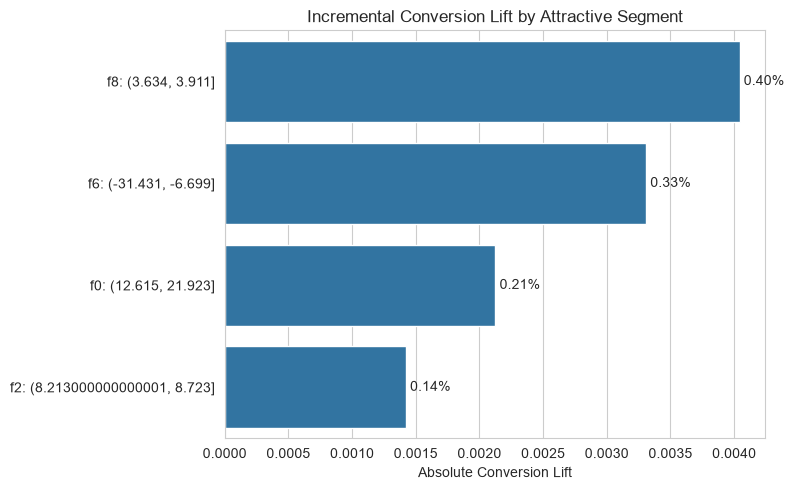

In [67]:
#Visualization 1: Incremental Lift by Segment
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=attractive_segments,
    x="absolute_lift",
    y="segment_label",
    ax=ax
)

ax.set_xlabel("Absolute Conversion Lift")
ax.set_ylabel("")
ax.set_title("Incremental Conversion Lift by Attractive Segment")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.2%}"
            for value in attractive_segments["absolute_lift"]
        ],
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/segment_incremental_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:

conversion_plot_data = attractive_segments[
    [
        "segment_label",
        "treatment_conversion_rate",
        "control_conversion_rate"
    ]
].melt(
    id_vars="segment_label",
    var_name="group",
    value_name="conversion_rate"
)

conversion_plot_data["group"] = conversion_plot_data[
    "group"
].replace({
    "treatment_conversion_rate": "Treatment",
    "control_conversion_rate": "Control"
})

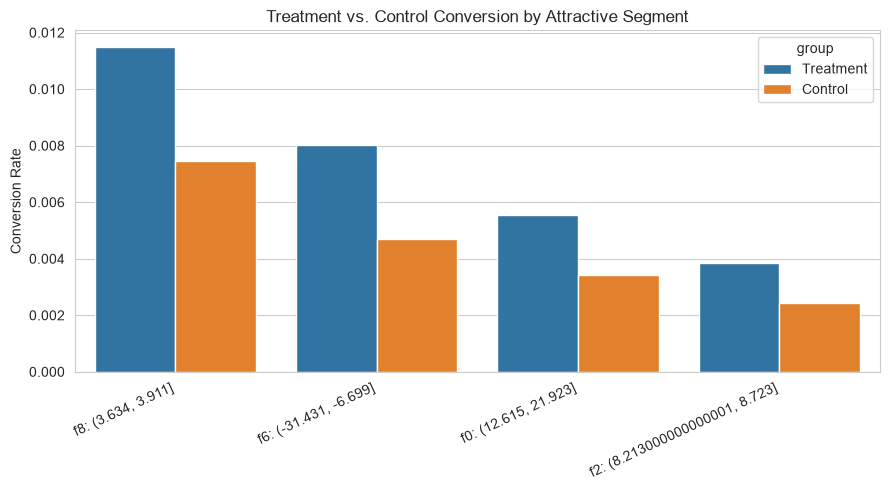

In [69]:
#Visualization 2: Treatment vs Control Conversion
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=conversion_plot_data,
    x="segment_label",
    y="conversion_rate",
    hue="group",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Conversion Rate")
ax.set_title("Treatment vs. Control Conversion by Attractive Segment")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/segment_treatment_vs_control.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

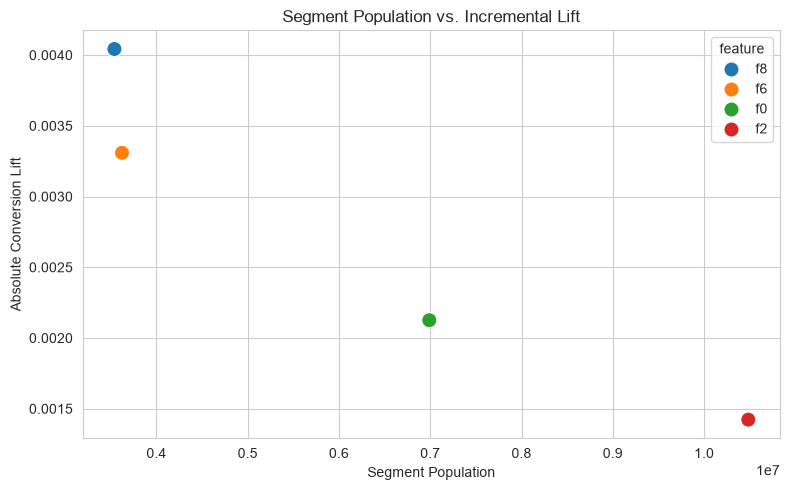

In [70]:
#Visualization 3: Segment Population vs. Incremental Lift
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=attractive_segments,
    x="segment_population",
    y="absolute_lift",
    hue="feature",
    s=120,
    ax=ax
)

ax.set_xlabel("Segment Population")
ax.set_ylabel("Absolute Conversion Lift")
ax.set_title("Segment Population vs. Incremental Lift")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/segment_population_vs_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

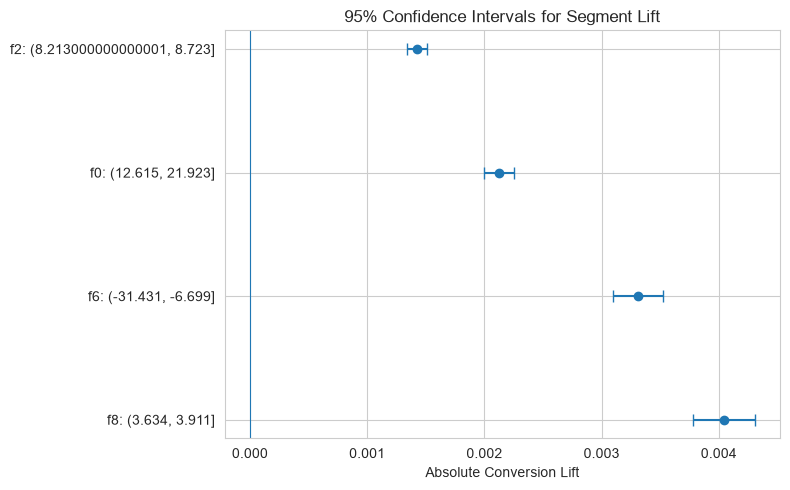

In [71]:
#Visualization 4: Confidence Intervals
fig, ax = plt.subplots(figsize=(8, 5))

y_positions = range(len(attractive_segments))

ax.errorbar(
    attractive_segments["absolute_lift"],
    y_positions,
    xerr=[
        attractive_segments["absolute_lift"]
        - attractive_segments["ci_lower"],
        attractive_segments["ci_upper"]
        - attractive_segments["absolute_lift"]
    ],
    fmt="o",
    capsize=4
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_yticks(list(y_positions))
ax.set_yticklabels(
    attractive_segments["segment_label"]
)

ax.set_xlabel("Absolute Conversion Lift")
ax.set_ylabel("")
ax.set_title("95% Confidence Intervals for Segment Lift")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/segment_lift_confidence_intervals.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [72]:
#the final segment table
import os

os.makedirs("../outputs/tables", exist_ok=True)

final_segment_summary.to_csv(
    "../outputs/tables/segment_incrementality_summary.csv",
    index=False
)